# Self-generated RFI in EIGSEP: 2025 characterisation and the 2026 before/after

Paper trail for the self-RFI statements in the EIGSEP instrument paper (RASTI).
Everything the manuscript says about self-RFI should be derivable from this
notebook.

## What this establishes

1. **2025 (deployment 4)** carried a duty-cycled broadband emitter and a
   population of persistent narrowband lines.
2. **2026 (deployment 5)**, after RFI mitigation, the duty-cycled emitter is
   **strongly suppressed** -- 1.2 per cent of integrations below the threshold
   that flagged 9.2 per cent of the 2025 night data on the same band, and the
   dropout event rate falls 1.5 -> 0.14 per hour. That is **about a factor of
   ten**, over 49.8 h of night data. This is the robust result. Quote it
   night-to-night on the matched band; see section 4a, and do not quote ~50x.
3. **A majority of the 2025 narrowband lines are gone**, and of those that
   remain, most are *stronger* than in 2025 -- which is what external sources
   do between epochs and what our own emitters cannot do after mitigation. The
   line census is more sensitive to the choice of window and threshold than the
   dropout census, so the fraction should be quoted as measured here, not
   treated as exact.

## What it deliberately does NOT establish

**Where the emitters were.** The earlier analysis concluded "on the rotating
platform" from a comparison of the *fraction of each antenna's own total power*
the emitter contributes. That is not a field-strength comparison -- it folds in
each antenna's bandpass, gain and sky coupling. Section 3 below redoes it
gain-free, referenced to the received calibration comb (the method
`radiated_selfRFI_lines.ipynb` already uses correctly for the lines), and the
answer flips: above 70 MHz the emitter is *closer to the ground antennas*. The
rotation test does not settle it either, because the metal platform 40 cm below
the antenna shadows a ground source just as effectively as it carries an
on-board one.

**Conclusion: the manuscript should not localise these emitters.**

## Two traps that have already produced wrong numbers

- **Correlator key 0 in 2025 is viv2, whose front-end is dead** (~37 dB low on
  both pols, no comb visible). Its flatness is a dead receiver, not evidence of
  near-field geometry. It is excluded everywhere below. The healthy ground
  antenna is viv1, present as two polarisations: cache label `3` = viv1-E,
  `ground` = viv1-N.
- **The comb residue differs by epoch.** 2025 tones sit on `ch % 16 == 0`;
  2026 on `ch % 16 == 8`, with a weaker second-polarisation set on residue 0
  (the transmitter was upgraded to dual polarisation). Masking the wrong
  residue puts transmitter tones inside a nominally clean band.

## Sources

| What | Where |
|---|---|
| 2025 cached spectra and census | `../deployment4/cache_dropout_{metadata,passA,passB}.npz` |
| 2025 raw correlator files | **not on this machine** -- the caches are the input |
| 2026 correlator files | `data/deployment5_filtered/` (~10 GB, local) |
| Prior notebooks | branch `chb-self-rfi`: `noise_dropouts_selfRFI`, `radiated_selfRFI_lines`, `explore_24h_july19_20`, `paper_selfrfi_figure` |

In [1]:
import glob
import json
from datetime import datetime, timezone
from zoneinfo import ZoneInfo
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

MTN = ZoneInfo("America/Denver")

REPO = Path.cwd().resolve()
while not (REPO / "data").is_dir():
    if REPO.parent == REPO:
        raise FileNotFoundError("repo root with data/ not found above cwd")
    REPO = REPO.parent

D4 = REPO / "notebooks" / "christian" / "deployment4"     # 2025 caches
D5 = REPO / "data" / "deployment5_filtered"               # 2026 correlator files
OUT = Path.cwd()

NCHAN = 1024
DF = 500.0 / 2048                     # MHz per channel = 0.244140625
freq = np.arange(NCHAN) * DF
COMB25 = np.arange(NCHAN) % 16 == 0   # 2025: residue 0
COMB26 = np.arange(NCHAN) % 8 == 0    # 2026: residue 8 plus a weaker residue-0 set
SWAP = datetime(2025, 7, 18, 18, 0, tzinfo=MTN).timestamp()   # bowtie key 4 -> 2

print(f"repo   {REPO}")
print(f"2025   {D4}")
print(f"2026   {D5}  ({len(list(D5.glob('corr_*.h5')))} files)")

repo   /home/christian/Documents/research/eigsep/data-analysis
2025   /home/christian/Documents/research/eigsep/data-analysis/notebooks/christian/deployment4
2026   /home/christian/Documents/research/eigsep/data-analysis/data/deployment5_filtered  (5120 files)


## 1. 2025 -- the duty-cycled emitter

`noise_dropouts_selfRFI.ipynb` found that arp's "noise dropouts" are the
*off*-windows of something otherwise always on. The census is rebuilt here from
the cached band-power series so the numbers are reproducible without the raw
files.

In [2]:
meta = np.load(D4 / "cache_dropout_metadata.npz")
passA = np.load(D4 / "cache_dropout_passA.npz")
sw_t, sw_s = meta["sw_t"], meta["sw_s"]
times_c = passA["times_c"]


def antenna_mask(t, sw_t, sw_s, guard=5.0):
    "sw_state == 0 is the antenna position; drop +-guard s around transitions."
    ix = np.clip(np.searchsorted(sw_t, t, side="right") - 1, 0, len(sw_t) - 1)
    ant = sw_s[ix] == 0
    chg = sw_t[1:][np.diff(sw_s) != 0]
    j = np.searchsorted(chg, t)
    for off in (-1, 0):
        jj = np.clip(j + off, 0, len(chg) - 1)
        ant &= np.abs(t - chg[jj]) > guard
    return ant


ant25 = antenna_mask(times_c, sw_t, sw_s)
bow = np.where(times_c < SWAP, passA["bow4"], passA["bow2"]).astype(float)
bow[~ant25] = np.nan
good = np.isfinite(bow)
fi = np.interp(times_c, times_c[good], bow[good])
base = median_filter(fi, size=int(35 * 60 / 1.07), mode="nearest")
with np.errstate(all="ignore"):
    r25 = 10 * np.log10(fi / base)
r25[~good] = np.nan

THR = -0.7
low = np.nan_to_num(r25) < THR
d_ = np.diff(low.astype(int))
st, en = np.nonzero(d_ == 1)[0] + 1, np.nonzero(d_ == -1)[0] + 1
runs = []
for s, e in zip(st, en):
    if runs and times_c[s] - times_c[runs[-1][1]] < 120:
        runs[-1][1] = e
    else:
        runs.append([s, e])
ev25 = np.array([(times_c[s], times_c[e] - times_c[s]) for s, e in runs
                 if 120 < times_c[e] - times_c[s] < 600])

def hr_local(t):
    d = datetime.fromtimestamp(t, tz=MTN)
    return d.hour + d.minute / 60


# The 2026 comparison below is night-only (the 2026 phase-C data is), so the
# 2025 side has to be night-only too or the comparison is not like for like.
night25 = np.array([(h >= 20.5) or (h <= 9.5) for h in map(hr_local, times_c)])
r25n = np.where(night25, r25, np.nan)
g25n = np.isfinite(r25n)
h25n = g25n.sum() * 1.07 / 3600
frac25 = np.mean(r25[np.isfinite(r25)] < THR)             # all hours, legacy
frac25n = np.mean(r25n[g25n] < THR)                       # night, for the comparison
mad25 = 1.4826 * np.nanmedian(np.abs(r25 - np.nanmedian(r25)))
mad25n = 1.4826 * np.nanmedian(np.abs(r25n - np.nanmedian(r25n)))
ev25n = ev25[np.array([(hr_local(t0) >= 20.5) or (hr_local(t0) <= 9.5)
                       for t0 in ev25[:, 0]])]
rate25n = len(ev25n) / h25n
print(f"2025: {np.isfinite(r25).sum()} antenna-state integrations")
print(f"  {len(ev25)} dropout events, median duration {np.median(ev25[:, 1]):.0f} s")
print(f"  {100 * frac25:.2f} per cent of antenna time below {THR} dB (all hours)")
print(f"  detrended floor MAD {mad25:.3f} dB (all hours)")
print(f"\n  night only (20:30-09:30 MDT), the basis of the 2026 comparison:")
print(f"    {g25n.sum()} integrations = {h25n:.1f} h")
print(f"    {100 * frac25n:.2f} per cent below {THR} dB, MAD {mad25n:.3f} dB")
print(f"    {len(ev25n)} events -> {rate25n:.2f} per hour")

2025: 183325 antenna-state integrations
  91 dropout events, median duration 233 s
  12.11 per cent of antenna time below -0.7 dB (all hours)
  detrended floor MAD 0.287 dB (all hours)

  night only (20:30-09:30 MDT), the basis of the 2026 comparison:
    84173 integrations = 25.0 h
    9.23 per cent below -0.7 dB, MAD 0.082 dB
    38 events -> 1.52 per hour


### Level of the emitter, band by band

Per-event paired on/off ratio: each dropout is compared with its own +-9 min
baseline, so sky drift and FM fading cancel. `1 - 1/ratio` is the fraction of
the total measured power the emitter contributes.

The headline number in the older notebooks -- "7-11 per cent across
40-150 MHz" -- does not survive being resolved in frequency: it is carried by
40-50 MHz, which is *below* the 50-250 MHz operating band, plus 100-150 MHz.

In [3]:
pB = np.load(D4 / "cache_dropout_passB.npz")
ANTS = ["bowtie", "ground", "3"]     # viv2 (key 0) excluded: dead front-end
LABEL = {"bowtie": "suspended bowtie", "ground": "viv1-N (ground)", "3": "viv1-E (ground)"}
ok = {p: (pB[f"cin_{p}"].min(axis=1) >= 50) & (pB[f"cout_{p}"].min(axis=1) >= 100)
      for p in ANTS}

on25, off25 = {}, {}
for p in ANTS:
    on25[p] = np.nanmedian(pB[f"sout_{p}"][ok[p]] / pB[f"cout_{p}"][ok[p]], axis=0)
    off25[p] = np.nanmedian(pB[f"sin_{p}"][ok[p]] / pB[f"cin_{p}"][ok[p]], axis=0)

frac_bowtie = 1.0 - off25["bowtie"] / on25["bowtie"]
nontx25 = ~COMB25
print("Emitter as a fraction of total measured power, suspended bowtie:")
for f0, f1 in [(40, 50), (50, 100), (100, 150), (150, 250), (50, 250)]:
    b = nontx25 & (freq >= f0) & (freq <= f1)
    tag = "  <- below the operating band" if f1 <= 50 else ""
    print(f"  {f0:3d}-{f1:3d} MHz: {100 * np.nanmedian(frac_bowtie[b]):5.1f} per cent{tag}")
print("\nThe defensible statement is band-resolved: ~10 per cent over 100-150 MHz,")
print("~2 per cent elsewhere in 50-250 MHz.")

Emitter as a fraction of total measured power, suspended bowtie:
   40- 50 MHz:  25.3 per cent  <- below the operating band
   50-100 MHz:   7.0 per cent
  100-150 MHz:  11.9 per cent
  150-250 MHz:   1.7 per cent
   50-250 MHz:   3.8 per cent

The defensible statement is band-resolved: ~10 per cent over 100-150 MHz,
~2 per cent elsewhere in 50-250 MHz.


## 2. The duty cycle looks thermal, not scheduled

A digital device on a timer gives a tight, time-of-day-invariant period. This
does not: the interval between off-windows is ~2.5x shorter in the afternoon
than overnight while the off-duration stays fixed -- a roughly constant recovery
time with a load-dependent interval, which is what a thermostatted compressor
does.

Checked against detrend windows from 15 to 90 min so it is not an artefact of
the 35-min detrending. It is **suggestive, not conclusive**: the overnight
sequence is not monotonic with ambient temperature and there are only 5-12
events per bin.

In [4]:
def census(win_min, thr=THR):
    b = median_filter(fi, size=int(win_min * 60 / 1.07), mode="nearest")
    with np.errstate(all="ignore"):
        r = 10 * np.log10(fi / b)
    r[~good] = np.nan
    lo = np.nan_to_num(r) < thr
    dd = np.diff(lo.astype(int))
    a_, b_ = np.nonzero(dd == 1)[0] + 1, np.nonzero(dd == -1)[0] + 1
    rr = []
    for s, e in zip(a_, b_):
        if rr and times_c[s] - times_c[rr[-1][1]] < 120:
            rr[-1][1] = e
        else:
            rr.append([s, e])
    return np.array([(times_c[s], times_c[e] - times_c[s]) for s, e in rr
                     if 120 < times_c[e] - times_c[s] < 600])


def local_hours(ts):
    return np.array([datetime.fromtimestamp(t, MTN).hour
                     + datetime.fromtimestamp(t, MTN).minute / 60 for t in ts])


print("Median start-to-start interval [min] by local time, vs detrend window")
print(f"{'window':>8} {'N':>4} |  00-06   06-12   12-18   18-24")
for win in (15, 25, 35, 60, 90):
    ev = census(win)
    h = local_hours(ev[:, 0])[:-1]
    g = np.diff(ev[:, 0]) / 60.0
    sel = g < 120
    row = []
    for h0 in (0, 6, 12, 18):
        m = sel & (h >= h0) & (h < h0 + 6)
        row.append(f"{np.median(g[m]):6.1f}" if m.sum() > 2 else "     -")
    print(f"{win:>6} m {len(ev):>4} | {'  '.join(row)}")

h25 = local_hours(ev25[:, 0])
night25 = (h25 >= 20.5) | (h25 <= 9.5)
print(f"\nOFF duration is stable while the interval varies ~4x:")
print(f"  night {np.median(ev25[night25, 1]):.0f} s, day {np.median(ev25[~night25, 1]):.0f} s")

tc = meta["tc_v"]
print(f"\nOn-platform thermal controller: {len(meta['tc_t'])} reports, "
      f"unique rows {np.unique(tc, axis=0).tolist()}, "
      f"{np.count_nonzero(np.any(np.diff(tc, axis=0) != 0, axis=1))} changes")
print("  -> it never ran. Excluded as the emitter.")
print(f"Motor stream: {len(meta['mot_t'])} record(s) -> no motor power-state telemetry.")

Median start-to-start interval [min] by local time, vs detrend window
  window    N |  00-06   06-12   12-18   18-24
    15 m  103 |   33.1    20.9    13.2    35.5
    25 m   98 |   33.1    16.2    12.2    70.3
    35 m   91 |   33.1    19.2    13.0    53.8
    60 m   95 |   33.1    15.3    12.0    31.2
    90 m   82 |   33.1    22.1    12.0    29.4

OFF duration is stable while the interval varies ~4x:
  night 221 s, day 242 s



On-platform thermal controller: 172462 reports, unique rows [[0.0, 0.0, 0.0, 0.0]], 0 changes
  -> it never ran. Excluded as the emitter.
Motor stream: 1 record(s) -> no motor power-state telemetry.


## 3. Localisation, done gain-free -- and why the old answer flips

The comb is radiated from the **ground** transmitter. Referencing the emitter's
power to the received comb cancels each receiver's gain, so:

- source beside the transmitter (on the ground) -> ratio roughly antenna-independent;
- source on the platform -> ratio much larger on the bowtie.

Note the direction of any selection bias: dropout events were *selected* on a
bowtie dip in 95-110 + 125-150 MHz, so this test is rigged in the bowtie's
favour. It still comes out the other way above 70 MHz.

In [5]:
comb_idx = np.nonzero(COMB25)[0]
emitter, combpow = {}, {}
for p in ANTS:
    emitter[p] = on25[p] - off25[p]
    cont = np.array([np.nanmean(on25[p][max(0, c - 6):c + 7][nontx25[max(0, c - 6):c + 7]])
                     for c in comb_idx])
    combpow[p] = on25[p][COMB25] - cont


def comb_ref(p, f0, f1):
    b = nontx25 & (freq >= f0) & (freq < f1)
    sel = (freq[comb_idx] >= f0) & (freq[comb_idx] < f1)
    pc = np.nansum(combpow[p][sel])
    return np.nansum(emitter[p][b]) / pc if pc > 0 else np.nan


print("Comb-referenced emitter power (gain-free). Larger = electrically closer.\n")
print(f"{'band [MHz]':>12} {'bowtie':>9} {'viv1-N':>9} {'viv1-E':>9}   nearer")
for f0 in range(30, 170, 20):
    v = {p: comb_ref(p, f0, f0 + 20) for p in ANTS}
    g = np.nanmean([v["ground"], v["3"]])
    verdict = "platform" if v["bowtie"] > 3 * g else ("GROUND" if g > 3 * v["bowtie"] else "ambiguous")
    print(f"{f0:5d}-{f0 + 20:<6d} {v['bowtie']:9.3f} {v['ground']:9.3f} {v['3']:9.3f}   {verdict}")

for f0, f1 in [(40, 65), (100, 150), (30, 160)]:
    v = {p: comb_ref(p, f0, f1) for p in ANTS}
    g = np.nanmean([v["ground"], v["3"]])
    print(f"\n  {f0}-{f1} MHz: bowtie/ground = {v['bowtie'] / g:.1f}x")
print("\nFor comparison, radiated_selfRFI_lines.ipynb gives the same statistic for the")
print("244 MHz line: bowtie 0.0017, viv1-E 1.14, viv1-N 0.26 -> ~700x stronger on the")
print("ground antennas. Section 5 shows that line is external anyway.")

Comb-referenced emitter power (gain-free). Larger = electrically closer.

  band [MHz]    bowtie    viv1-N    viv1-E   nearer
   30-50         0.833     0.414     4.260   ambiguous
   50-70         0.127     0.021     0.091   ambiguous
   70-90         0.056     0.062     0.367   GROUND
   90-110        0.396     0.465     1.454   ambiguous
  110-130        0.109     0.081     0.692   GROUND
  130-150        0.038     0.544     0.464   GROUND
  150-170        0.006     0.052     0.015   GROUND

  40-65 MHz: bowtie/ground = 4.0x

  100-150 MHz: bowtie/ground = 0.1x

  30-160 MHz: bowtie/ground = 0.3x

For comparison, radiated_selfRFI_lines.ipynb gives the same statistic for the
244 MHz line: bowtie 0.0017, viv1-E 1.14, viv1-N 0.26 -> ~700x stronger on the
ground antennas. Section 5 shows that line is external anyway.


## 4. 2026 -- did it go away?

Same detector, same band, same threshold, same hours, applied to the 2026
suspended bowtie (`box-air`, correlator key 4). The detrend runs inside
contiguous segments so it never spans a data gap.

**"Same band" has to be worked for.** The 2025 series in
`cache_dropout_passA.npz` was built on `95-110 | 125-150 MHz`
(`noise_dropouts_selfRFI.ipynb`, cell 17), *not* on 100-150, and the 2025 raw
correlator files are not on this machine -- so 2025 cannot be moved onto a
different band. 2026 is therefore computed on the 2025 band. This matters: the
threshold is an *absolute* -0.7 dB cut, the detrended floor's MAD changes by a
factor of ten across plausible bands (the 2025 band carries 13 MHz of FM in
40 MHz, against 8 in 50 for 100-150), and an unmatched band changes the
answer by about a factor of five. Section 4a shows the size of the effect.

In [6]:
# MATCHED to the 2025 cache band. See the note above; `BANDS` keeps the two
# alternatives so section 4a can show what the choice is worth.
BANDS = {
    "matched 95-110|125-150": (~COMB26) & (((freq >= 95) & (freq <= 110))
                                           | ((freq >= 125) & (freq <= 150))),
    "unmatched 100-150": (~COMB26) & (freq >= 100) & (freq <= 150),
    "FM-free 110-150": (~COMB26) & (freq >= 110) & (freq <= 150),
}
BAND = "matched 95-110|125-150"
band_flt = BANDS[BAND]
T, B, BALL = [], [], {k: [] for k in BANDS}
for fn in sorted(D5.glob("corr_2026071[5678]*.h5")):
    try:
        with h5py.File(fn, "r") as f:
            if "4" not in f["data"]:
                continue
            t = f["header/times"][:]
            sw = np.array([s == "RFANT" for s in json.loads(f["metadata/rfswitch"][()])])
            d = f["data/4"][:].astype(float)
            n = min(len(sw), len(d), len(t))
            d, t_, m = d[:n], t[:n], sw[:n]
            hh = np.array([datetime.fromtimestamp(x, timezone.utc).hour
                           + datetime.fromtimestamp(x, timezone.utc).minute / 60 for x in t_])
            night = (hh >= 2.5) & (hh <= 15.5)          # 20:30-09:30 MDT
            bmn = d[:, band_flt].mean(1)
            keep = m & night & (bmn > 0) & np.isfinite(bmn)
            if keep.any():
                T.append(t_[keep]); B.append(bmn[keep])
                for k, bm in BANDS.items():
                    BALL[k].append(d[keep][:, bm].mean(1))
    except (OSError, KeyError):
        continue

t26 = np.concatenate(T); b26 = np.concatenate(B)
o = np.argsort(t26); t26, b26 = t26[o], b26[o]
BALL = {k: np.concatenate(v)[o] for k, v in BALL.items()}
segs = np.split(np.arange(len(t26)), np.nonzero(np.diff(t26) > 600)[0] + 1)

W = int(35 * 60 / 1.07)


def census26(bb_all, thr=THR):
    # Detrend per segment, then count integrations below thr and 2-10 min
    # events. Returns (detrended, n_int, n_below, median segment MAD, n_events).
    out, tot, low, mads, nev = [], 0, 0, [], 0
    for s in segs:
        if len(s) < W:
            continue
        bb, tt = bb_all[s], t26[s]
        g = np.isfinite(bb) & (bb > 0)
        if g.sum() < W:
            continue
        bb, tt = bb[g], tt[g]
        rr = 10 * np.log10(bb / median_filter(bb, size=W, mode="nearest"))
        f = np.isfinite(rr)
        rr, tt = rr[f], tt[f]
        out.append(rr)
        tot += len(rr); low += np.count_nonzero(rr < thr)
        mads.append(1.4826 * np.median(np.abs(rr - np.median(rr))))
        lowm = rr < thr
        d_ = np.diff(lowm.astype(int))
        st_, en_ = np.nonzero(d_ == 1)[0] + 1, np.nonzero(d_ == -1)[0] + 1
        k = min(len(st_), len(en_))
        runs_ = []
        for a, b in zip(st_[:k], en_[:k]):
            if runs_ and tt[a] - tt[runs_[-1][1]] < 120:
                runs_[-1][1] = b
            else:
                runs_.append([a, b])
        nev += sum(1 for a, b in runs_ if 120 < tt[b] - tt[a] < 600)
    return np.concatenate(out), tot, low, float(np.median(mads)), nev


r26_all, tot26, low26, mad26, nev26 = census26(b26)
h26 = tot26 * 1.07 / 3600
frac26 = low26 / tot26
rate26 = nev26 / h26

print(f"2026 phase C, night, band {BAND}: {len(segs)} segments, "
      f"{tot26} integrations ({h26:.1f} h)")
print(f"  below {THR} dB: {low26}  ({100 * frac26:.3f} per cent)")
print(f"  detrended floor MAD {mad26:.3f} dB")
print(f"  {nev26} events of 2-10 min -> {rate26:.3f} per hour\n")
print(f"2025, night, same band: {100 * frac25n:.2f} per cent below threshold, "
      f"MAD {mad25n:.3f} dB, {len(ev25n)} events -> {rate25n:.2f} per hour\n")
print(f"  At the 2025 night rate, {frac25n * tot26:.0f} of these {tot26} integrations")
print(f"  would be in a dropout. Observed {low26}  ->  {frac25n / frac26:.1f}x reduction.")
print(f"  Dropout event rate falls {rate25n:.2f} -> {rate26:.3f} per hour "
      f"({rate25n / rate26:.0f}x).")

2026 phase C, night, band matched 95-110|125-150: 8 segments, 167507 integrations (49.8 h)
  below -0.7 dB: 1939  (1.158 per cent)
  detrended floor MAD 0.226 dB
  7 events of 2-10 min -> 0.141 per hour

2025, night, same band: 9.23 per cent below threshold, MAD 0.082 dB, 38 events -> 1.52 per hour

  At the 2025 night rate, 15455 of these 167507 integrations
  would be in a dropout. Observed 1939  ->  8.0x reduction.
  Dropout event rate falls 1.52 -> 0.141 per hour (11x).


## 4a. How much of the improvement is the band choice?

An earlier version of this notebook ran the 2026 detector on 100-150 MHz while
the 2025 series was on `95-110 | 125-150`, and quoted the ratio between them as
the headline. That is not a valid comparison, and it is worth ~5x.

The reason is that `-0.7 dB` is an absolute cut on a series whose noise depends
on the band. The table prints the cut in units of each band's own MAD. Where
that number is large the detector is not measuring the same thing any more.

The matched row is the one the manuscript quotes. Note also that the FM-free
band is much the quietest -- if the 2025 raw files are ever recovered, redoing
both epochs on 110-150 MHz would give a far cleaner comparison than either.

In [7]:
print(f"2025 night, 95-110|125-150 : {100 * frac25n:7.3f} per cent below {THR} dB, "
      f"MAD {mad25n:.3f} dB ({0.7 / mad25n:4.1f} sigma), "
      f"{len(ev25n):3d} events, {rate25n:.2f}/h")
print()
for k, bm in BANDS.items():
    _, tot_, low_, mad_, nev_ = census26(BALL[k])
    h_ = tot_ * 1.07 / 3600
    print(f"2026 night, {k:22s}: {100 * low_ / tot_:7.3f} per cent, "
          f"MAD {mad_:.3f} dB ({0.7 / mad_:4.1f} sigma), "
          f"{nev_:3d} events, {nev_ / h_:.3f}/h"
          f"   -> {frac25n / (low_ / tot_):5.1f}x fewer integrations, "
          f"{rate25n / (nev_ / h_) if nev_ else float('inf'):5.1f}x fewer events")
print("\nA threshold rescaled to a matched *significance* (2.4 sigma) instead of a")
print("matched amplitude is NOT the right alternative: a relative cut is scale-free,")
print("so it returns the same tail fraction of whatever noise remains. At")
print(f"2.4 x {mad26:.3f} = {2.4 * mad26:.2f} dB those excursions are noise, not dropouts.")
print("The absolute cut is the physical one: 0.7 dB is ~15 per cent of total power,")
print("and the 2025 dropouts had a median depth of 1.12 dB.")

2025 night, 95-110|125-150 :   9.226 per cent below -0.7 dB, MAD 0.082 dB ( 8.6 sigma),  38 events, 1.52/h

2026 night, matched 95-110|125-150:   1.158 per cent, MAD 0.226 dB ( 3.1 sigma),   7 events, 0.141/h   ->   8.0x fewer integrations,  10.8x fewer events
2026 night, unmatched 100-150     :   0.227 per cent, MAD 0.126 dB ( 5.6 sigma),   2 events, 0.040/h   ->  40.7x fewer integrations,  37.8x fewer events
2026 night, FM-free 110-150       :   0.153 per cent, MAD 0.023 dB (31.1 sigma),   1 events, 0.020/h   ->  60.4x fewer integrations,  75.6x fewer events

A threshold rescaled to a matched *significance* (2.4 sigma) instead of a
matched amplitude is NOT the right alternative: a relative cut is scale-free,
so it returns the same tail fraction of whatever noise remains. At
2.4 x 0.226 = 0.54 dB those excursions are noise, not dropouts.
The absolute cut is the physical one: 0.7 dB is ~15 per cent of total power,
and the 2025 dropouts had a median depth of 1.12 dB.


## 5. Which narrowband lines survived?

Line excess is the spectrum divided by its own 17-channel running median, in dB,
so it is insensitive to each receiver's bandpass. Computed on the 2025 night
spectrum (emitter on) and the 2026 night spectrum, both for the suspended
bowtie.

The direction of change is a useful first cut, but **"it got stronger, so it is
external" does not follow on its own.** Two alternatives have to be excluded:
mitigation that made a line *worse* (a new shield can resonate, or change
coupling), and **new emitters introduced in 2026** -- the lidar, the azimuth
potentiometer, the second ground receiver and the dual-polarization transmitter
are all new, and all sit on or near the ground station. Section 5b tests for
both.

Caveat: this uses every phase-C night, so it is deeper than the 2025 spectrum
and picks up weak external lines the 2025 data could not see. A shorter 2026
window gives a larger "gone" fraction. Quote the direction-of-change tally, not
the survival count.

In [8]:
T2, ACC, CNT = [], np.zeros(NCHAN), np.zeros(NCHAN)
for fn in sorted(D5.glob("corr_2026071[678]*.h5")):
    try:
        with h5py.File(fn, "r") as f:
            if "4" not in f["data"]:
                continue
            t = f["header/times"][:]
            sw = np.array([s == "RFANT" for s in json.loads(f["metadata/rfswitch"][()])])
            d = f["data/4"][:].astype(float)
            n = min(len(sw), len(d), len(t))
            hh = np.array([datetime.fromtimestamp(x, timezone.utc).hour
                           + datetime.fromtimestamp(x, timezone.utc).minute / 60
                           for x in t[:n]])
            keep = sw[:n] & (hh >= 2.5) & (hh <= 15.5)      # 20:30-09:30 MDT
            dd = d[:n][keep]
            v = (dd > 0) & (dd < 1.5e9)
            ACC += np.where(v, dd, 0).sum(0); CNT += v.sum(0)
    except (OSError, KeyError):
        continue
sp26 = ACC / np.maximum(CNT, 1)
print(f"2026 night spectrum: {CNT.max():.0f} integrations at best-covered channel")


def line_excess(sp):
    sm = median_filter(sp, 17, mode="nearest")
    with np.errstate(all="ignore"):
        e = 10 * np.log10(np.abs(sp / np.where(sm > 0, sm, 1)))
    e[0] = np.nan
    return e


e25 = line_excess(on25["bowtie"])
e26 = line_excess(sp26)

band = (freq >= 50) & (freq <= 246)
fm = (freq >= 88) & (freq <= 108)
is25 = band & ~fm & ~COMB25 & (np.nan_to_num(e25) > 0.5)
surv = is25 & (np.nan_to_num(e26) > 0.5)
idx = np.nonzero(is25)[0]
d_line = e26[idx] - e25[idx]
print(f"\n{is25.sum()} lines in 2025;  {surv.sum()} still >0.5 dB in 2026;  {(is25 & ~surv).sum()} gone")
print(f"  weaker in 2026: {np.count_nonzero(d_line < 0)}   stronger: {np.count_nonzero(d_line > 0)}")
print(f"  median change among those that weakened : {np.median(d_line[d_line < 0]):+.2f} dB")
print(f"  median change among those that grew     : {np.median(d_line[d_line > 0]):+.2f} dB")
print("  -> direction of change only; see section 5b before attributing these.")
print(f"\n{'MHz':>8} {'2025':>7} {'2026':>7}  status")
for ch in np.nonzero(is25)[0]:
    print(f"{freq[ch]:8.2f} {e25[ch]:+7.2f} {e26[ch]:+7.2f}  "
          f"{'SURVIVED' if surv[ch] else 'gone'}")

2026 night spectrum: 157571 integrations at best-covered channel

55 lines in 2025;  23 still >0.5 dB in 2026;  32 gone
  weaker in 2026: 33   stronger: 22
  median change among those that weakened : -1.13 dB
  median change among those that grew     : +5.13 dB
  -> direction of change only; see section 5b before attributing these.

     MHz    2025    2026  status
   63.96   +0.71   +0.84  SURVIVED
  111.82   +0.61   -0.12  gone
  112.06   +0.70   +3.09  SURVIVED
  113.53   +1.10   -0.10  gone
  114.50   +1.19   -0.14  gone
  114.75   +0.79   -0.17  gone
  114.99   +0.58  +14.04  SURVIVED
  115.97   +1.51   +3.36  SURVIVED
  116.21   +1.17   -0.03  gone
  117.43   +1.27   -0.19  gone
  117.68   +0.96   -0.11  gone
  118.90   +1.56  +12.53  SURVIVED
  120.36   +0.82   -0.25  gone
  121.58   +1.35   +0.29  gone
  121.83   +1.85   -0.16  gone
  123.05   +1.34  +14.97  SURVIVED
  123.29   +1.32   -0.10  gone
  124.51   +1.10   -0.12  gone
  124.76   +0.81   -0.12  gone
  125.98   +0.78   

### The 244 MHz feature is not ours -- and not digital TV either

It is **~20 dB stronger** in 2026 than 2025, which no mitigation story explains.
Its shape is a handful of discrete carriers spread over ~10 MHz with deep gaps
between them, not the flat ~6 MHz block an ATSC digital-TV channel produces --
and 225-328.6 MHz is not a US TV allocation in any case (VHF-high TV ends at
216 MHz). It also swings by >25 dB through the night. Narrowband, intermittent
carriers in that band are consistent with military aeronautical / UHF satellite
traffic.

Its exact coincidence with channel 1000 (= 1000 x 500/2048 MHz) is what made it
look clock-derived. Channelisation only localises a tone to about +-60 kHz, so a
single coincidence is weak evidence -- the notebook that reported it said so.

In [9]:
print("Shape near 244 MHz in 2026 (dB over local continuum):")
for ch in range(988, 1012):
    print(f"  {freq[ch]:8.3f}  ch{ch:4d}  {e26[ch]:+6.2f}  {'#' * max(0, int(e26[ch] * 1.5))}")
wide = [ch for ch in range(960, 1024) if e26[ch] > 3]
print(f"\n  {len(wide)} channels > +3 dB, spanning "
      f"{freq[min(wide)]:.2f}-{freq[max(wide)]:.2f} MHz -- discrete spikes, not a flat block")

Shape near 244 MHz in 2026 (dB over local continuum):
   241.211  ch 988   +0.54  
   241.455  ch 989   +9.78  ##############
   241.699  ch 990   -4.57  
   241.943  ch 991  +13.27  ###################
   242.188  ch 992   -6.15  
   242.432  ch 993   -7.24  
   242.676  ch 994   -8.22  
   242.920  ch 995  +17.74  ##########################
   243.164  ch 996   -0.65  
   243.408  ch 997   -8.22  
   243.652  ch 998   -1.11  
   243.896  ch 999  +22.53  #################################
   244.141  ch1000  +21.14  ###############################
   244.385  ch1001   +0.65  
   244.629  ch1002   -6.44  
   244.873  ch1003   +9.74  ##############
   245.117  ch1004  +12.32  ##################
   245.361  ch1005   -4.42  
   245.605  ch1006   -5.21  
   245.850  ch1007   -5.09  
   246.094  ch1008  +14.83  ######################
   246.338  ch1009  +11.56  #################
   246.582  ch1010   -2.13  
   246.826  ch1011   -6.87  

  24 channels > +3 dB, spanning 234.86-249.27 MHz -- di

## 5b. Are the lines that grew actually external?

Two discriminators, both computed from 761 night file-averages spanning 72.5 h,
using the two 2026 receivers -- `box-air` (suspended, ~90 m up) and `box-gnd`
(fixed on the ground, beside the new hardware).

**Air minus ground.** Every emitter added in 2026 is on or near the ground
station. A new on-site emitter must therefore be much louder on `box-gnd` than
on the suspended antenna. A distant source reaches both similarly.

**Night-to-night scatter.** Instrument hardware runs steadily; sky and traffic
sources come and go.

Neither is proof on its own, and a *worsened* on-instrument emitter is not
formally excluded -- but it would have to be symmetric between two receivers
90 m apart, which is a strong constraint.

In [10]:
# per-file night spectra for both 2026 receivers, so we can measure scatter
recs = {"4": [], "0": []}
for fn in sorted(D5.glob("corr_2026071[5678]*.h5")):
    try:
        with h5py.File(fn, "r") as f:
            if "4" not in f["data"] or "0" not in f["data"]:
                continue
            t = f["header/times"][:]
            sw = np.array([x == "RFANT" for x in json.loads(f["metadata/rfswitch"][()])])
            n = min(len(sw), len(t), len(f["data/4"]), len(f["data/0"]))
            hh = np.array([datetime.fromtimestamp(x, timezone.utc).hour
                           + datetime.fromtimestamp(x, timezone.utc).minute / 60 for x in t[:n]])
            keep = sw[:n] & (hh >= 2.5) & (hh <= 15.5)
            if keep.sum() < 30:
                continue
            sp = {}
            for k in ("4", "0"):
                d = f[f"data/{k}"][:n][keep].astype(float)
                v = (d > 0) & (d < 1.5e9); c = v.sum(0)
                sp[k] = np.where(c >= 10, np.where(v, d, 0).sum(0) / np.maximum(c, 1), np.nan)
            if np.isfinite(sp["4"][200:900]).all() and np.isfinite(sp["0"][200:900]).all():
                for k in ("4", "0"):
                    recs[k].append(sp[k])
    except (OSError, KeyError):
        continue

E4 = np.array([line_excess(x) for x in recs["4"]])
E0 = np.array([line_excess(x) for x in recs["0"]])
m4, m0 = np.nanmedian(E4, axis=0), np.nanmedian(E0, axis=0)
iqr4 = np.nanpercentile(E4, 75, axis=0) - np.nanpercentile(E4, 25, axis=0)
print(f"{E4.shape[0]} night file-averages, both receivers")

grew_ch = idx[d_line > 0]
ag = m4[grew_ch] - m0[grew_ch]
iq = iqr4[grew_ch]
print(f"\nThe {len(grew_ch)} lines that grew:")
print(f"  median air-ground asymmetry : {np.median(ag):+.2f} dB")
print(f"  |air-ground| > 6 dB         : {np.count_nonzero(np.abs(ag) > 6)} of {len(grew_ch)}")
print(f"  night-to-night IQR > 3 dB   : {np.count_nonzero(iq > 3)} of {len(grew_ch)}"
      f"   (median {np.median(iq):.1f} dB)")
print("\nNone of these 22 is asymmetric.")
print("\nDo NOT contrast this against the 'three orders of magnitude between")
print("antennas metres apart' figure from the older notebooks. That came from")
print("correlator key 0, which in 2025 is viv2 with a dead front-end, and the")
print("2025 ground antennas were ~100 m from the bowtie, not metres. The 2025")
print("comparison that IS gain-free points at the ground station, and the one")
print("line it was strongest for (244 MHz) turns out to be external anyway.")
print("The symmetry above stands on its own; it needs no 2025 foil.")

aero = (freq[grew_ch] >= 108) & (freq[grew_ch] <= 137)
print(f"\n{np.count_nonzero(aero)} of {len(grew_ch)} sit in the aeronautical band"
      f" (108-137 MHz), where VOR/ILS beacons and aircraft voice traffic live --")
print("consistent with their large night-to-night scatter.")

/home/christian/Documents/research/eigsep/data-analysis/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/christian/Documents/research/eigsep/data-analysis/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


761 night file-averages, both receivers

The 22 lines that grew:
  median air-ground asymmetry : +0.02 dB
  |air-ground| > 6 dB         : 0 of 22
  night-to-night IQR > 3 dB   : 17 of 22   (median 6.0 dB)

None of these 22 is asymmetric.

Do NOT contrast this against the 'three orders of magnitude between
antennas metres apart' figure from the older notebooks. That came from
correlator key 0, which in 2025 is viv2 with a dead front-end, and the
2025 ground antennas were ~100 m from the bowtie, not metres. The 2025
comparison that IS gain-free points at the ground station, and the one
line it was strongest for (244 MHz) turns out to be external anyway.
The symmetry above stands on its own; it needs no 2025 foil.

9 of 22 sit in the aeronautical band (108-137 MHz), where VOR/ILS beacons and aircraft voice traffic live --
consistent with their large night-to-night scatter.


## 6. The confound that must be stated

The 2026 phase-C data was taken with the **calibration transmitter off**
(tone/continuum ~0 dB, against +16.6 dB band-median when on in 2025).
`explore_24h_july19_20.ipynb` showed the transmitter at full power raises the
non-comb floor by +0.23 dB band-median, with bumps of +1-2 dB at 90-135 MHz and
+3.2 dB near 172 MHz, and it ran ~94 per cent of the night in 2025.

So the 2026 improvement has **two** possible contributors: the RFI mitigation
fitted between deployments, and the transmitter being off. They are not
separable in this data set.

The duty-cycled dropouts are a separate matter -- the comb was constant to
+-0.1 dB *through* the 2025 dropouts, so the emitter was not the transmit chain.
But the overall floor comparison cannot be attributed to mitigation alone, and
the manuscript should not claim it is.

In [11]:
# compare each candidate tone with its OWN immediate neighbours, so the
# comparison is local and the bandpass shape cannot masquerade as a tone
def tone_over_local(sp, residue, lo=60, hi=900):
    r = []
    for c in np.nonzero(np.arange(NCHAN) % 16 == residue)[0]:
        if not (lo <= c <= hi):
            continue
        nb = [c + o for o in (-6, -5, -4, 4, 5, 6) if 0 <= c + o < NCHAN]
        r.append(10 * np.log10(sp[c] / np.nanmedian(sp[nb])))
    return np.nanmedian(r)

print(f"2026 comb check, tone over local continuum:")
for res in (8, 0):
    print(f"  residue {res}: {tone_over_local(sp26, res):+.2f} dB")
print(f"  a non-comb residue (4), as a null: {tone_over_local(sp26, 4):+.2f} dB")
print("  (2025 with the transmitter on: +16.6 dB band median)")
print("  -> confirms the transmitter was OFF in the 2026 phase-C data.")

2026 comb check, tone over local continuum:
  residue 8: +1.86 dB
  residue 0: +0.71 dB
  a non-comb residue (4), as a null: -0.14 dB
  (2025 with the transmitter on: +16.6 dB band median)
  -> confirms the transmitter was OFF in the 2026 phase-C data.


## 7. Figure

Three panels, all on the suspended antenna.

**(a) and (b)** are the emitter's duty cycle in the time domain: six hours of
band-averaged power over `95-110 | 125-150 MHz` -- the band the 2025 cache was
built on, which 2026 is matched to (section 4a) -- detrended by a 35-minute
running median and binned to 30 s so single-integration RFI transients do not
dominate. The square notches in 2025 are the emitter switching off. 2026 is the
same quantity over the same band and the same duration.

The sign is worth stating plainly, because it is what made the first version of
this figure unreadable: the emitter is on ~88 per cent of the time, so the
running median *is* "emitter on", and the emitter switching off reads as a dip.

**(c)** restates it the right way round and is what the referee actually asked
for -- how much power the emitter contributed, against frequency, as a fraction
of the total measured. Binned to 10 MHz, because the per-channel difference is
too noisy to read and would suggest a flat 10-20 per cent across the band, which
is not what the band medians say. It exists only for 2025: in 2026 there are no
off-windows to difference, which is the result.

saved selfrfi_2025_2026.pdf
2025 18756 integrations -> 687 bins; 2026 39665 -> 712 bins

10 MHz binned emitter contribution [per cent]:
    55.0 MHz    6.8
    65.0 MHz    6.3
    75.0 MHz    4.9
    85.0 MHz    3.6
   115.0 MHz   11.9
   125.0 MHz   13.2
   135.0 MHz   15.3
   145.0 MHz    4.0
   155.0 MHz    2.6
   165.0 MHz    4.3
   175.0 MHz    7.0
   185.0 MHz    0.3
   195.0 MHz    1.3
   205.0 MHz    1.5
   215.0 MHz    0.5
   225.0 MHz    0.0
   235.0 MHz    2.0
   245.0 MHz    2.6


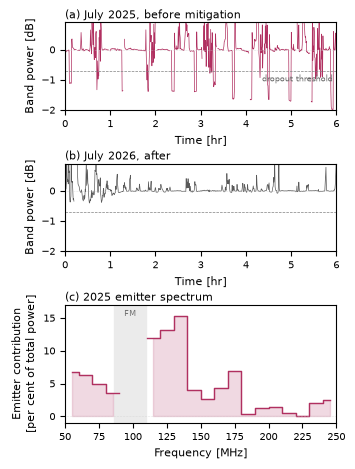

In [12]:
def binned(x, y, width):
    "median of y in bins of x"
    edges = np.arange(x.min(), x.max() + width, width)
    c = 0.5 * (edges[:-1] + edges[1:])
    v = np.array([np.nanmedian(y[(x >= a) & (x < b)]) if np.any((x >= a) & (x < b))
                  else np.nan for a, b in zip(edges[:-1], edges[1:])])
    return c, v


# --- time series -----------------------------------------------------------
w0 = datetime(2025, 7, 20, 2, 0, tzinfo=MTN).timestamp()
m25 = (times_c >= w0) & (times_c <= w0 + 6 * 3600) & good
t25p, y25p = binned((times_c[m25] - w0) / 3600.0, r25[m25], 30 / 3600)

best = max(segs, key=len)
bb = b26[best]
rr = 10 * np.log10(bb / median_filter(bb, size=W, mode="nearest"))
tt = (t26[best] - t26[best][0]) / 3600.0
k6 = tt <= 6.0
t26p, y26p = binned(tt[k6], rr[k6], 30 / 3600)

fig = plt.figure(figsize=(3.5, 5.2))
gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 1.35], hspace=0.55)

for row, (tp, yp, col, lbl) in enumerate([
        (t25p, y25p, "#b03060", "(a) July 2025, before mitigation"),
        (t26p, y26p, "0.35", "(b) July 2026, after")]):
    ax = fig.add_subplot(gs[row])
    ax.plot(tp, yp, lw=0.5, color=col)
    ax.axhline(0, color="0.8", lw=0.4, ls=":")
    ax.axhline(THR, color="0.5", lw=0.5, ls="--")
    ax.set_xlim(0, 6)
    ax.set_ylim(-2.0, 0.9)
    ax.set_yticks([0, -1, -2])
    ax.tick_params(labelsize=7)
    ax.set_title(lbl, fontsize=8, loc="left", pad=3)
    ax.set_xlabel("Time [hr]", fontsize=8)
    if row == 0:
        ax.set_ylabel("Band power [dB]", fontsize=8)
        ax.text(5.92, THR - 0.12, "dropout threshold", fontsize=5.5,
                ha="right", va="top", color="0.4")
    else:
        ax.set_ylabel("Band power [dB]", fontsize=8)

# --- spectrum --------------------------------------------------------------
ax = fig.add_subplot(gs[2])
pc = 100.0 * frac_bowtie
pc[COMB25] = np.nan
selb = (freq >= 50) & (freq <= 250) & ~((freq > 86) & (freq < 110))
fc, fv = binned(freq[selb], pc[selb], 10.0)
ax.step(fc, fv, where="mid", lw=1.0, color="#b03060")
ax.fill_between(fc, 0, fv, step="mid", color="#b03060", alpha=0.18)
ax.axvspan(86, 110, color="0.92", zorder=0)
ax.text(98, 15.3, "FM", fontsize=6, ha="center", color="0.45")
ax.axhline(0, color="0.8", lw=0.4, ls=":")
ax.set_xlim(50, 250)
ax.set_ylim(-1, 17)
ax.set_xlabel("Frequency [MHz]", fontsize=8)
ax.set_ylabel("Emitter contribution\n[per cent of total power]", fontsize=8)
ax.tick_params(labelsize=7)
ax.set_title("(c) 2025 emitter spectrum", fontsize=8, loc="left", pad=3)

for ext in ("pdf", "png"):
    fig.savefig(OUT / f"selfrfi_2025_2026.{ext}", dpi=200, bbox_inches="tight")
print("saved selfrfi_2025_2026.pdf")
print(f"2025 {m25.sum()} integrations -> {np.isfinite(y25p).sum()} bins; "
      f"2026 {k6.sum()} -> {np.isfinite(y26p).sum()} bins")
print("\n10 MHz binned emitter contribution [per cent]:")
for c_, v_ in zip(fc, fv):
    if np.isfinite(v_):
        print(f"  {c_:6.1f} MHz  {v_:5.1f}")

## 8. Export

Compact, self-contained arrays for the paper repo -- no raw data, Zenodo-safe.

In [13]:
np.savez_compressed(
    OUT / "selfrfi_2025_2026.npz",
    freq_mhz=freq,
    excess_2025=e25, excess_2026=e26,
    comb_mask_2025=COMB25, comb_mask_2026=COMB26,
    spec_2025_on=on25["bowtie"], spec_2025_off=off25["bowtie"], spec_2026=sp26,
    detrended_2025=r25n[g25n], detrended_2026=r26_all,
    detrended_2025_all_hours=r25[np.isfinite(r25)],
    dropout_events_2025=ev25,
    frac_below_thr=np.array([frac25n, frac26]),
    frac_below_thr_2025_all_hours=frac25,
    n_integrations=np.array([int(g25n.sum()), tot26]),
    exposure_hours=np.array([h25n, h26]),
    n_events=np.array([len(ev25n), nev26]),
    mad_db=np.array([mad25n, mad26]),
    band_mask=band_flt,
    threshold_db=THR,
    description=(
        "EIGSEP self-RFI, deployment 4 (Jul 2025) vs deployment 5 (Jul 2026), "
        "suspended bowtie. excess_* = spectrum / 17-channel running median [dB]. "
        "detrended_* = band-mean power over the comb-masked band 95-110 | "
        "125-150 MHz (band_mask) / 35-min running median [dB]. Both epochs are "
        "night only (20:30-09:30 local) and on the same band; see section 4a for "
        "why that matters. frac_below_thr, n_integrations, exposure_hours, "
        "n_events, mad_db = [2025, 2026]. NOTE: the 2026 data was taken with the "
        "calibration transmitter off, which contributes to the improvement "
        "alongside the RFI mitigation."),
)
print("wrote selfrfi_2025_2026.npz")

wrote selfrfi_2025_2026.npz


## 9. What the manuscript can say

**Supported:**

- Self-generated interference was identified in the July 2025 field data: a
  duty-cycled broadband emitter, off for ~4 min roughly every half hour, and a
  population of persistent narrowband lines.
- Between 100 and 150 MHz the duty-cycled emitter contributed of order **ten per
  cent** of the total measured power on the suspended antenna, falling to the
  **per cent level** elsewhere in 50-250 MHz.
- After mitigation, the July 2026 data shows the duty-cycled emitter strongly
  suppressed: over 49.8 h of night observation, **1.2 per cent** of integrations
  fall below the threshold that flagged **9.2 per cent** of the 2025 night data
  on the same band -- and the rate of 2-10 min dropout events falls from
  **1.5 to 0.14 per hour**. Quote this as **about a factor of ten**, and quote
  it night-to-night on the matched band.
  **Do not quote ~50x.** That figure came from comparing 2025 over all hours on
  `95-110 | 125-150` against 2026 over night only on `100-150`; two mismatches,
  worth ~5x between them. Section 4a shows the size of each.
- A majority of the 2025 narrowband lines are gone; those that remain are mostly
  *stronger* than in 2025, which identifies them as external rather than ours.
- The 244 MHz feature in particular is ~20 dB stronger in 2026, so it is not
  ours, and its shape is discrete carriers over ~10 MHz rather than a flat 6 MHz
  block, so it is not digital TV either.

**Must be stated alongside it:** the 2026 data was taken with the calibration
transmitter off, so mitigation is not the only possible cause of the
improvement.

**Must NOT be claimed:**

- that self-RFI is the *dominant* systematic -- it has never been compared with
  calibration error, beam mis-modelling or terrain coupling;
- where the emitters are -- the gain-free test contradicts the earlier
  on-platform conclusion and the rotation test does not separate the cases;
- that the 244 MHz line is ours;
- any impact on usable observing bandwidth beyond what is quoted above.

## 10. Open follow-ups

- **Per-subsystem power-cycling audit** at the next deployment -- the only thing
  that will identify the device.
- **A transmitter-on stretch in 2026** would separate mitigation from the
  transmitter being off. Phases A/B (Jul 12-15) use different correlator keys
  and were not checked here.
- **FAA/NTIA allocation cross-check** for the 109-137 MHz forest and the
  239-249 MHz carriers.
- **Cross-phase triangulation** of the surviving lines, using the `04` baseline.